# Preamble

In [1]:
import numpy as np
import pandas as pd
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import os
from glob import glob
from sklearn.preprocessing import StandardScaler
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Data Processing

In [2]:
def get_eeg_loader(data_root, batch_size=32, normalize=False):
    """
    Data loader for multi-channel EEG CSV files with variable lengths
    """

    # Prepare data paths and labels
    data_paths = []
    labels = []
    classes = ['control', 'stimulation']

    for label, class_name in enumerate(classes):
        class_path = os.path.join(data_root, class_name)
        csv_files = glob(os.path.join(class_path, '*.csv'))
        data_paths.extend(csv_files)
        labels.extend([label] * len(csv_files))

    print(f"Found {len(data_paths)} files")

    # First, check all file lengths
    file_lengths = []
    for path in data_paths:
        df = pd.read_csv(path, header=0)
        file_lengths.append(len(df))

    print(f"\nFile length statistics:")
    print(f"  Min length: {min(file_lengths)} time points")
    print(f"  Max length: {max(file_lengths)} time points")
    print(f"  Mean length: {np.mean(file_lengths):.0f} time points")
    print(f"  Std length: {np.std(file_lengths):.0f} time points")

    # Find the minimum length to trim all files to
    target_length = min(file_lengths)
    # Or use a fixed length like 24000 and trim/pad
    # target_length = 24000

    print(f"\nTrimming all files to {target_length} time points")

    # Calculate new slice size based on trimmed length
    slices_per_file = 4
    slice_size = target_length // slices_per_file
    print(f"Each slice will be {slice_size} time points")

    # Load all data to compute per-channel statistics
    if normalize:
        print("\nComputing per-channel normalization statistics...")
        all_channels_data = [[] for _ in range(4)]

        for path in data_paths:
            df = pd.read_csv(path, header=0)
            data = df.values.astype(np.float32)

            # Trim to target length
            data = data[:target_length, :]

            # Extract electrode data (columns 2-5)
            electrode_data = data[:, 1:5]

            for ch in range(4):
                all_channels_data[ch].extend(electrode_data[:, ch])

        # Compute per-channel mean and std
        channel_means = []
        channel_stds = []
        for ch in range(4):
            ch_data = np.array(all_channels_data[ch])
            channel_means.append(np.mean(ch_data))
            channel_stds.append(np.std(ch_data))
            print(f"Channel {ch+1}: Mean = {channel_means[-1]:.4f}, Std = {channel_stds[-1]:.4f}")

    # Now load, trim, slice, and normalize
    all_slices = []
    all_slice_labels = []

    for path, label in zip(data_paths, labels):
        df = pd.read_csv(path, header=0)
        data = df.values.astype(np.float32)

        # Trim to target length
        data = data[:target_length, :]

        # Extract electrode data (columns 2-5)
        electrode_data = data[:, 1:5]

        # Slice into equal parts
        for i in range(slices_per_file):
            start = i * slice_size
            end = start + slice_size
            slice_data = electrode_data[start:end, :]

            # Normalize if requested
            if normalize:
                normalized_slice = np.zeros_like(slice_data)
                for ch in range(4):
                    normalized_slice[:, ch] = (slice_data[:, ch] - channel_means[ch]) / (channel_stds[ch] + 1e-8)
                slice_data = normalized_slice

            # Transpose to (channels, time)
            slice_data = slice_data.T

            all_slices.append(slice_data)
            all_slice_labels.append(label)

    # Convert to numpy array
    X = np.array(all_slices)
    y = np.array(all_slice_labels)

    print(f"\nFinal data shape: {X.shape}")
    print(f"  - Total slices: {X.shape[0]}")
    print(f"  - Channels: {X.shape[1]}")
    print(f"  - Time points per slice: {X.shape[2]}")

    # Convert to tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)

    # Split
    total = len(dataset)
    train_size = int(0.8 * total)
    val_size = int(0.1 * total)
    test_size = total - train_size - val_size

    print(f"\nSplits - Train: {train_size}, Val: {val_size}, Test: {test_size}")

    generator = torch.Generator().manual_seed(42)
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
        generator=generator
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    norm_params = {'channel_means': channel_means, 'channel_stds': channel_stds} if normalize else None

    return train_loader, val_loader, test_loader, classes, norm_params

data_root = '/content/drive/MyDrive/aps360/Filtered_Data'
train_loader, val_loader, test_loader, classes, norm_params = get_eeg_loader(data_root, batch_size=128, normalize=True)

Found 236 files

File length statistics:
  Min length: 24000 time points
  Max length: 40114 time points
  Mean length: 24086 time points
  Std length: 1079 time points

Trimming all files to 24000 time points
Each slice will be 6000 time points

Computing per-channel normalization statistics...
Channel 1: Mean = 0.0019, Std = 6.3779
Channel 2: Mean = 0.0036, Std = 5.5292
Channel 3: Mean = 0.0032, Std = 7.3728
Channel 4: Mean = 0.0001, Std = 5.4784

Final data shape: (944, 4, 6000)
  - Total slices: 944
  - Channels: 4
  - Time points per slice: 6000

Splits - Train: 755, Val: 94, Test: 95


# CNN Model

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(CNN, self).__init__()
        self.name = "CNN"

        self.conv1 = nn.Conv1d(4, 32, kernel_size=7, padding=3)
        self.pool = nn.MaxPool1d(4)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=7, padding=2)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=7, padding=1)

        # Calculate the exact size after pooling
        # Input: 6000
        # After pool1: floor(6000/4) = 1500
        # After pool2: floor(1500/4) = 375
        # After pool3: floor(375/4) = 93? Let's check if it's actually 92
        # Let's compute explicitly:
        size = 6000
        size = size // 4  # pool1: 1500
        size = size // 4  # pool2: 375
        size = size // 4  # pool3: 93.75 → 93 with floor division

        # Based on error showing 11776, let's verify:
        # 128 * 92 = 11776 (this matches your error!)
        # So actual size after pooling is 92, not 93

        size = size  # This will be 93 with integer division
        # But PyTorch might be using floor differently
        # Let's use the safe approach:
        self.flattened_size = 128 * 92  # CHANGED: 93 → 92

        self.fc1 = nn.Linear(self.flattened_size, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [7]:
def train_net(model, train_loader, val_loader=None, learning_rate=0.001, num_epochs=5, plot=True):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    print(f"Using device: {device}")
    print(f"Model: {model.name if hasattr(model, 'name') else 'Unnamed'}")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-3)

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    # ADDED: Best model tracking
    best_val_acc = 0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # Training phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        batch_count = 0
        # CHANGED: 'images' → 'data' to be more generic
        for data, labels in train_loader:
            batch_count += 1
            data, labels = data.to(device), labels.to(device)

            # Forward pass
            outputs = model(data)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total

        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        print(f"  Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.2f}%")

        # Validation phase
        if val_loader is not None:
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for data, labels in val_loader:
                    data, labels = data.to(device), labels.to(device)
                    outputs = model(data)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item()

                    _, predicted = torch.max(outputs.data, 1)
                    val_total += labels.size(0)
                    val_correct += (predicted == labels).sum().item()

            val_epoch_loss = val_loss / len(val_loader)
            val_epoch_acc = 100 * val_correct / val_total

            val_losses.append(val_epoch_loss)
            val_accuracies.append(val_epoch_acc)

            # ADDED: Save best model
            if val_epoch_acc > best_val_acc:
                best_val_acc = val_epoch_acc
                best_model_state = model.state_dict().copy()
                print(f"  → New best model! Val Acc: {best_val_acc:.2f}%")

            print(f"  Val Loss: {val_epoch_loss:.4f}, Val Accuracy: {val_epoch_acc:.2f}%")
            print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")


    # ADDED: Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\nLoaded best model with validation accuracy: {best_val_acc:.2f}%")

    # Plot training and validation curves
    if plot:
        plt.figure(figsize=(14, 5))

        # Plot loss
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Training Loss', marker='o', linewidth=2)
        if val_loader is not None and val_losses:
            plt.plot(val_losses, label='Validation Loss', marker='s', linewidth=2)
        plt.title('Loss vs. Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)

        # Plot accuracy
        plt.subplot(1, 2, 2)
        plt.plot(train_accuracies, label='Training Accuracy', marker='o', linewidth=2)
        if val_loader is not None and val_accuracies:
            plt.plot(val_accuracies, label='Validation Accuracy', marker='s', linewidth=2)
        plt.title('Accuracy vs. Epochs')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # ADDED: Print final statistics
        print("\n" + "="*50)
        print("TRAINING COMPLETE")
        print("="*50)
        print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
        if val_accuracies:
            print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
            print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")
        print("="*50)

    return train_losses, train_accuracies, val_losses, val_accuracies

Using device: cpu
Model: CNN

Epoch 1/30
  Train Loss: 0.6894, Train Accuracy: 52.45%
  → New best model! Val Acc: 43.62%
  Val Loss: 0.7137, Val Accuracy: 43.62%
  LR: 0.000100

Epoch 2/30
  Train Loss: 0.6846, Train Accuracy: 52.45%
  Val Loss: 0.6958, Val Accuracy: 43.62%
  LR: 0.000100

Epoch 3/30
  Train Loss: 0.6743, Train Accuracy: 52.45%
  Val Loss: 0.6991, Val Accuracy: 43.62%
  LR: 0.000100

Epoch 4/30
  Train Loss: 0.6630, Train Accuracy: 52.58%
  → New best model! Val Acc: 50.00%
  Val Loss: 0.6769, Val Accuracy: 50.00%
  LR: 0.000100

Epoch 5/30
  Train Loss: 0.6488, Train Accuracy: 63.97%
  Val Loss: 0.6773, Val Accuracy: 50.00%
  LR: 0.000100

Epoch 6/30
  Train Loss: 0.6306, Train Accuracy: 64.50%
  → New best model! Val Acc: 71.28%
  Val Loss: 0.6407, Val Accuracy: 71.28%
  LR: 0.000100

Epoch 7/30
  Train Loss: 0.6135, Train Accuracy: 71.26%
  Val Loss: 0.6683, Val Accuracy: 60.64%
  LR: 0.000100

Epoch 8/30
  Train Loss: 0.6006, Train Accuracy: 70.46%
  Val Loss: 0.6

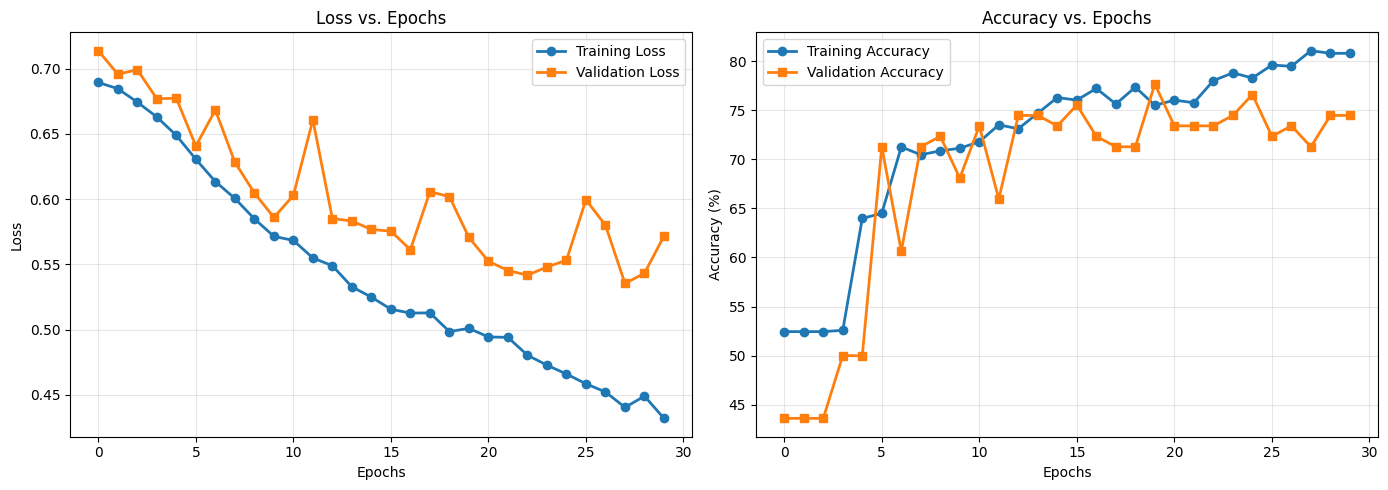


TRAINING COMPLETE
Final Training Accuracy: 80.79%
Best Validation Accuracy: 77.66%
Final Validation Accuracy: 74.47%


In [8]:
model = CNN()
train_losses, train_accuracies, val_losses, val_accuracies = train_net(model, train_loader, val_loader, learning_rate=0.0001, num_epochs=30, plot=True)


# Test

In [6]:
def evaluate_model(model, test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss()

    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(test_loader)

    print(f"Test Accuracy: {accuracy:.2f}%, Test Loss: {avg_loss:.4f}")
    return accuracy, avg_loss

test_acc, test_loss = evaluate_model(model, test_loader)

NameError: name 'model' is not defined